# SVB Event Exploration

## Research Context

This case examines a different source of stablecoin risk from the LUNA and Celsius events.

In the scenario modelled in this project, incoming volatile crypto payments are converted into **USDT**, which represents the operational balance.

USDC is included as a comparison stablecoin.

USDC is designed to maintain a value close to **$1**. Circle, the company behind USDC, supports this value with reserves held in cash and other highly liquid assets.

Part of Circle's cash reserves was held at **Silicon Valley Bank (SVB)**.

When SVB failed in March 2023, part of the real-world money supporting USDC became temporarily tied to a failed bank.

This creates an important comparison for the modelled operational strategy:

> **Can problems with the reserves supporting one stablecoin create substantial price instability, even while another stablecoin remains comparatively stable?**

The analysis therefore uses two layers:

1. **BTC and ETH — broader market context**  
   These assets show what was happening in the wider crypto market around the SVB failure.

2. **USDT and USDC — stablecoin comparison**  
   USDT represents the modelled operational balance, while USDC provides an event-specific comparison because part of its supporting reserves was held at SVB.

This case is used to examine **reserve and banking-infrastructure risk** and to test whether the choice of stablecoin can matter during a stress event.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 1. Daily Market Context

The daily analysis covers **7–17 March 2023**, capturing the broader crypto-market environment before and after the failure of Silicon Valley Bank.

BTC and ETH are used as indicators of broader market conditions.

The purpose is to determine whether the SVB failure coincided with a distinct crypto-market sell-off or occurred within an already changing market environment.

In [2]:
crypto_daily_processed = pd.read_csv('../data/processed/daily/crypto_daily_processed.csv', parse_dates=["date"])
crypto_daily_processed.head()

,date,btc_close,eth_close,usdc_close,usdt_close,btc_high,eth_high,usdc_high,usdt_high,btc_low,...,usdc_low,usdt_low,btc_open,eth_open,usdc_open,usdt_open,btc_volume,eth_volume,usdc_volume,usdt_volume
0,2020-01-01,7200.174316,130.802002,1.004079,0.999836,7254.330566,132.835358,1.006639,1.006873,7174.944336,...,1.001989,0.994924,7194.892090,129.630661,1.003730,0.999571,1.856566e+10,7.935230e+09,242586528.0,2.150314e+10
1,2020-01-02,6985.470215,127.410179,1.005017,1.001565,7212.155273,130.820038,1.012636,1.008451,6935.270020,...,1.002543,0.986515,7202.551270,130.820038,1.004431,0.999788,2.080208e+10,8.032709e+09,318268134.0,2.421231e+10
2,2020-01-03,7344.884277,134.171707,1.005273,1.004192,7413.715332,134.554016,1.007928,1.022286,6914.996094,...,0.988455,0.988027,6984.428711,127.411263,1.005357,1.001183,2.811148e+10,1.047685e+10,374792167.0,3.242029e+10
3,2020-01-04,7410.656738,135.069366,1.009466,1.007472,7427.385742,136.052719,1.018391,1.013633,7309.514160,...,1.001273,0.999160,7345.375488,134.168518,1.004818,1.003510,1.844427e+10,7.430905e+09,334494308.0,2.158563e+10
4,2020-01-05,7411.317383,136.276779,1.008497,1.006197,7544.497070,139.410202,1.018718,1.016161,7400.535645,...,1.003932,1.001758,7410.451660,135.072098,1.008748,1.009921,1.972507e+10,7.526675e+09,334597544.0,2.409014e+10


In [3]:
svb_daily = crypto_daily_processed[
    (crypto_daily_processed["date"] >= "2023-03-07") &
    (crypto_daily_processed["date"] <= "2023-03-17")
]
svb_daily[["date", "btc_close", "eth_close"]]

,date,btc_close,eth_close
1161,2023-03-07,22219.769531,1561.933105
1162,2023-03-08,21718.080078,1534.088257
1163,2023-03-09,20363.021484,1438.660767
1164,2023-03-10,20187.244141,1429.158081
1165,2023-03-11,20632.410156,1482.616699
1166,2023-03-12,22163.949219,1590.292969
1167,2023-03-13,24197.533203,1680.308960
1168,2023-03-14,24746.074219,1703.507080
1169,2023-03-15,24375.960938,1656.180542
1170,2023-03-16,25052.789062,1677.215454


In [4]:
svb_daily = svb_daily.copy()

svb_daily["btc_return_pct"] = (svb_daily["btc_close"].pct_change() * 100)

svb_daily["eth_return_pct"] = (svb_daily["eth_close"].pct_change() * 100)
svb_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='btc_return_pct')

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
1163,2023-03-09,20363.021484,1438.660767,-6.239311,-6.220469
1162,2023-03-08,21718.080078,1534.088257,-2.257852,-1.782717
1169,2023-03-15,24375.960938,1656.180542,-1.495644,-2.778183
1164,2023-03-10,20187.244141,1429.158081,-0.863218,-0.660523
1165,2023-03-11,20632.410156,1482.616699,2.205185,3.740567
1168,2023-03-14,24746.074219,1703.507080,2.266929,1.380587
1170,2023-03-16,25052.789062,1677.215454,2.776621,1.270086
1166,2023-03-12,22163.949219,1590.292969,7.422977,7.262583
1167,2023-03-13,24197.533203,1680.308960,9.175188,5.660340
1171,2023-03-17,27423.929688,1792.485107,9.464577,6.872680


In [5]:
svb_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='btc_return_pct', ascending=False).head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
1171,2023-03-17,27423.929688,1792.485107,9.464577,6.872680
1167,2023-03-13,24197.533203,1680.308960,9.175188,5.660340
1166,2023-03-12,22163.949219,1590.292969,7.422977,7.262583
1170,2023-03-16,25052.789062,1677.215454,2.776621,1.270086
1168,2023-03-14,24746.074219,1703.507080,2.266929,1.380587


In [6]:
svb_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='eth_return_pct').head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
1163,2023-03-09,20363.021484,1438.660767,-6.239311,-6.220469
1169,2023-03-15,24375.960938,1656.180542,-1.495644,-2.778183
1162,2023-03-08,21718.080078,1534.088257,-2.257852,-1.782717
1164,2023-03-10,20187.244141,1429.158081,-0.863218,-0.660523
1170,2023-03-16,25052.789062,1677.215454,2.776621,1.270086


In [7]:
svb_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='eth_return_pct', ascending=False).head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
1166,2023-03-12,22163.949219,1590.292969,7.422977,7.262583
1171,2023-03-17,27423.929688,1792.485107,9.464577,6.872680
1167,2023-03-13,24197.533203,1680.308960,9.175188,5.660340
1165,2023-03-11,20632.410156,1482.616699,2.205185,3.740567
1168,2023-03-14,24746.074219,1703.507080,2.266929,1.380587


Text(0, 0.5, 'BTC Price (USD)')

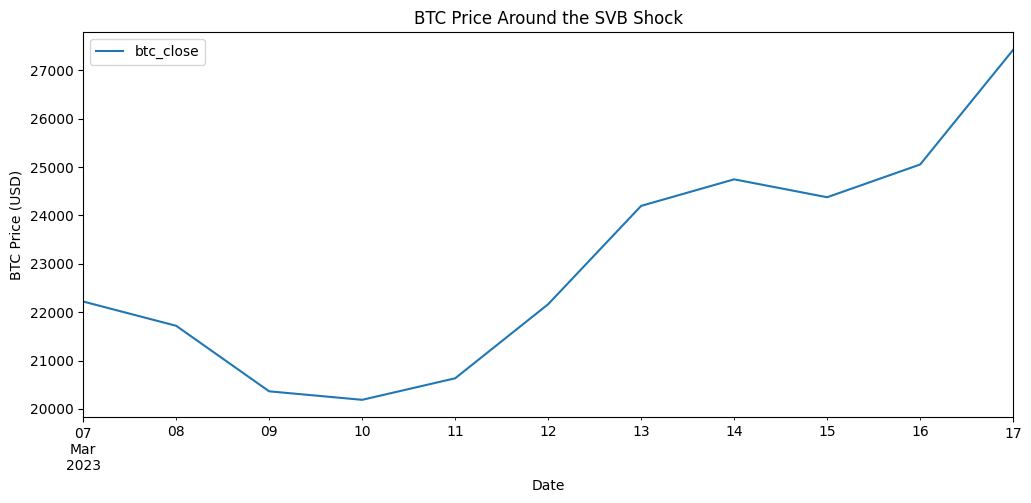

In [8]:
ax = svb_daily.plot(
    x="date",
    y="btc_close",
    figsize=(12, 5),
    title="BTC Price Around the SVB Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

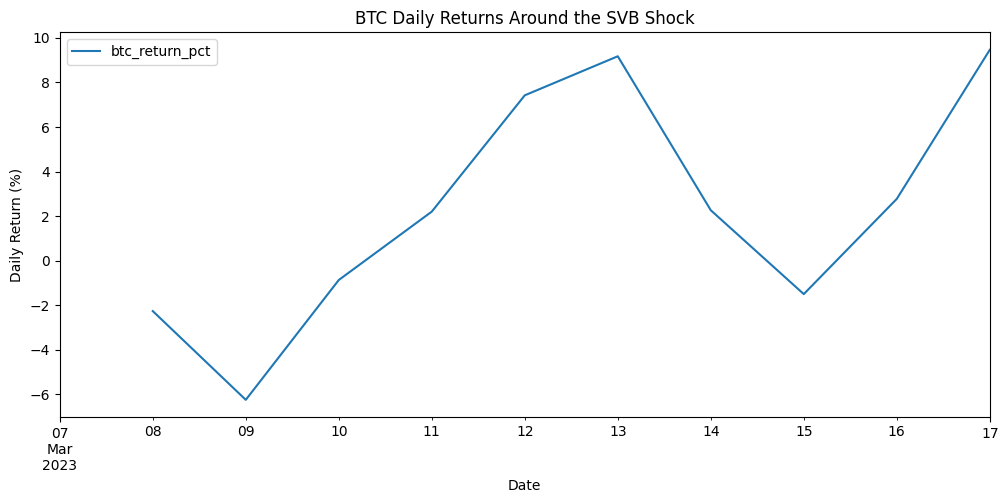

In [9]:
ax = svb_daily.plot(
    x="date",
    y="btc_return_pct",
    figsize=(12, 5),
    title="BTC Daily Returns Around the SVB Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

Text(0, 0.5, 'ETH Price (USD)')

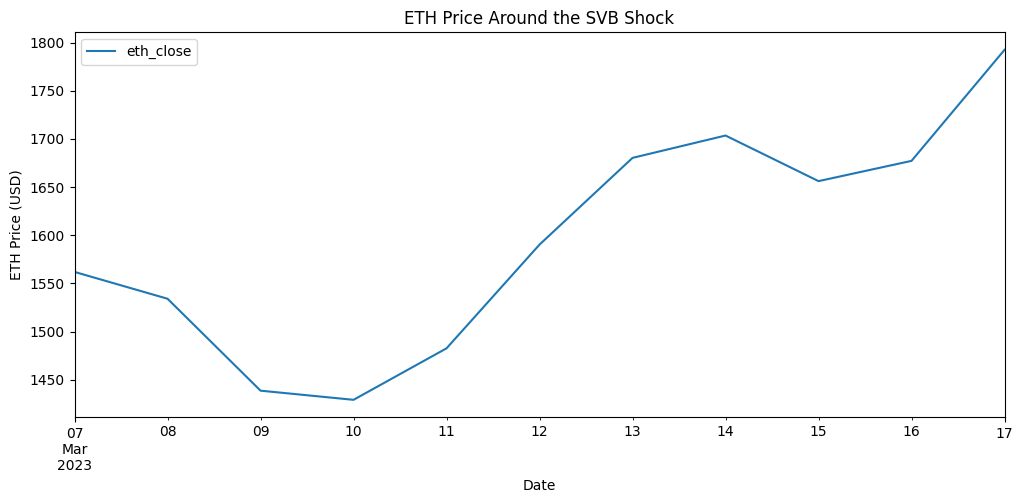

In [10]:
ax = svb_daily.plot(
    x="date",
    y="eth_close",
    figsize=(12, 5),
    title="ETH Price Around the SVB Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("ETH Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

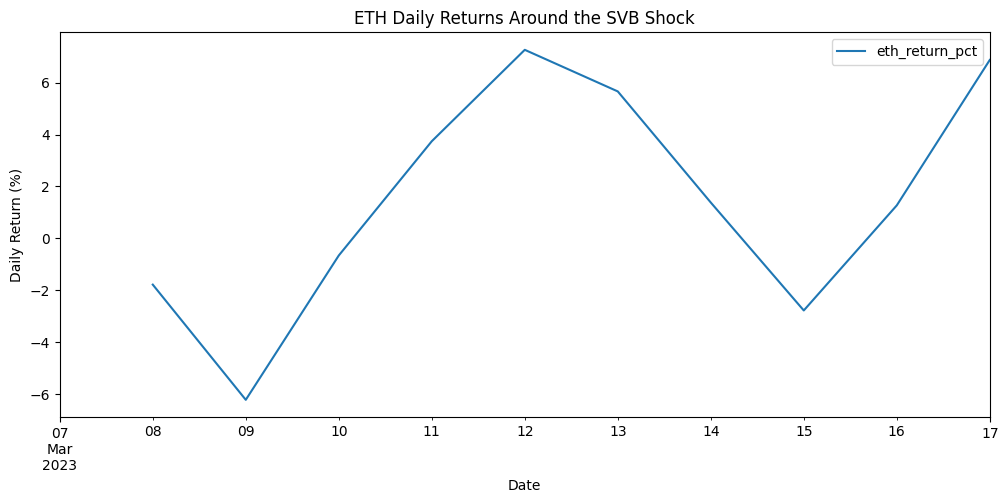

In [11]:
ax = svb_daily.plot(
    x="date",
    y="eth_return_pct",
    figsize=(12, 5),
    title="ETH Daily Returns Around the SVB Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

### Daily Observation

BTC and ETH were already under substantial selling pressure before the official closure of Silicon Valley Bank.

The largest daily decline in the selected window occurred on **9 March**, when BTC fell by approximately **6.24%** and ETH by **6.22%**.

On 10 March, the day SVB was closed, the declines were considerably smaller.

The market then reversed direction, with strong positive BTC and ETH returns during the following days.

The daily data therefore does not show a distinct crypto-market sell-off beginning with the SVB closure.

For this case, the more relevant risk appears in the stablecoin layer rather than in the broader BTC and ETH market.

## 2. Hourly Market Stress

The daily data suggests that broader crypto-market weakness began before the SVB closure.

Hourly BTC and ETH data provides a more detailed view of the timing of these movements.

The purpose is not to assume that SVB caused each price movement, but to understand where the banking event sits within the broader crypto-market environment.

In [12]:
btc_svb_hourly = pd.read_csv('../data/processed/hourly/binance/btc_svb_hourly_processed.csv', parse_dates=["open_time"])
btc_svb_hourly.head()

,open_time,open,high,low,close,volume
0,2023-02-24 00:00:00,23940.20,24022.87,23890.00,23958.71,9447.10151
1,2023-02-24 01:00:00,23958.71,24132.35,23956.80,24002.85,13218.58218
2,2023-02-24 02:00:00,24001.78,24029.91,23907.15,23940.42,9441.36012
3,2023-02-24 03:00:00,23940.42,23998.10,23921.46,23954.05,5655.48755
4,2023-02-24 04:00:00,23954.50,23986.12,23923.88,23942.21,6471.52290


In [13]:
svb_btc_detail = btc_svb_hourly[
    (btc_svb_hourly["open_time"] >= "2023-03-07") &
    (btc_svb_hourly["open_time"] < "2023-03-17")
].copy()

In [14]:
svb_btc_detail["btc_hourly_return_pct"] = (svb_btc_detail["close"].pct_change() * 100)
svb_btc_detail[["open_time", "close", "btc_hourly_return_pct"]].sort_values(by='btc_hourly_return_pct').head()

,open_time,close,btc_hourly_return_pct
332,2023-03-09 20:00:00,20116.66,-3.540026
450,2023-03-14 18:00:00,24990.18,-2.489713
367,2023-03-11 07:00:00,19850.81,-2.138567
330,2023-03-09 18:00:00,21012.89,-2.126602
452,2023-03-14 20:00:00,24570.06,-1.932175


In [15]:
svb_btc_detail[["open_time", "close", "btc_hourly_return_pct"]].sort_values(by='btc_hourly_return_pct', ascending=False).head()

,open_time,close,btc_hourly_return_pct
422,2023-03-13 14:00:00,23484.63,4.470668
444,2023-03-14 12:00:00,25832.57,4.403380
404,2023-03-12 20:00:00,21259.02,2.307462
423,2023-03-13 15:00:00,23981.72,2.116661
408,2023-03-13 00:00:00,22446.02,2.040768


Text(0, 0.5, 'BTC Price (USDT)')

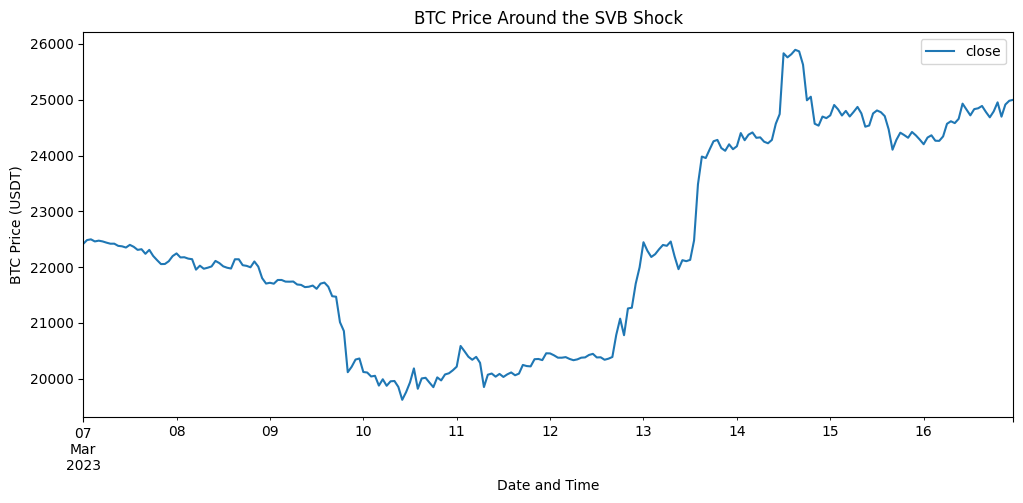

In [16]:
ax = svb_btc_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="BTC Price Around the SVB Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Price (USDT)")

Text(0, 0.5, 'BTC Hourly Returns (%)')

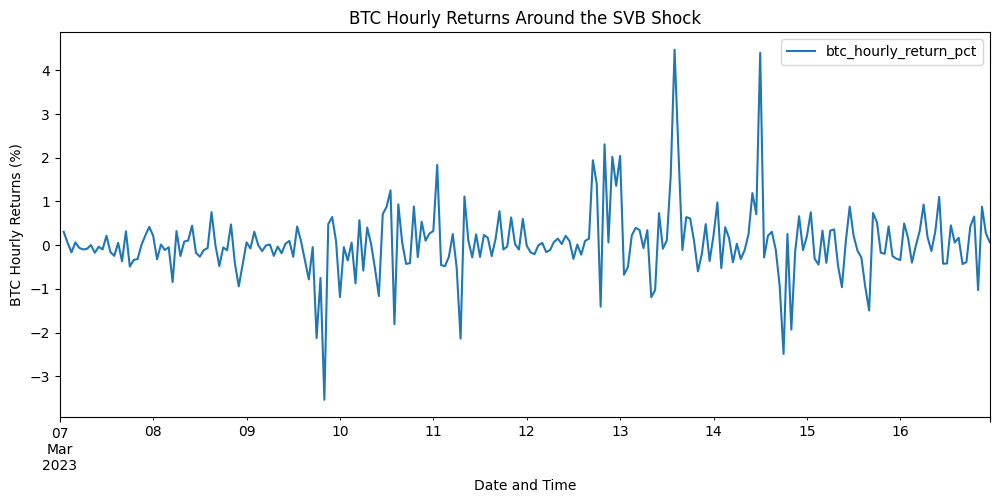

In [17]:
ax = svb_btc_detail.plot(
    x="open_time",
    y="btc_hourly_return_pct",
    figsize=(12, 5),
    title="BTC Hourly Returns Around the SVB Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Hourly Returns (%)")

In [18]:
eth_svb_hourly = pd.read_csv('../data/processed/hourly/binance/eth_svb_hourly_processed.csv', parse_dates=["open_time"])
eth_svb_hourly.head()

,open_time,open,high,low,close,volume
0,2023-02-24 00:00:00,1650.52,1657.39,1646.22,1651.50,13641.4736
1,2023-02-24 01:00:00,1651.49,1664.66,1651.49,1653.24,18798.9400
2,2023-02-24 02:00:00,1653.25,1655.50,1646.34,1648.48,13473.9456
3,2023-02-24 03:00:00,1648.49,1651.88,1646.04,1649.14,8491.8647
4,2023-02-24 04:00:00,1649.15,1651.47,1646.82,1647.04,7366.9808


In [19]:
svb_eth_detail = eth_svb_hourly[
    (eth_svb_hourly["open_time"] >= "2023-03-07") &
    (eth_svb_hourly["open_time"] < "2023-03-17")
].copy()

In [20]:
svb_eth_detail["eth_hourly_return_pct"] = (svb_eth_detail["close"].pct_change() * 100)
svb_eth_detail[["open_time", "close", "eth_hourly_return_pct"]].sort_values(by='eth_hourly_return_pct').head()

,open_time,close,eth_hourly_return_pct
332,2023-03-09 20:00:00,1414.70,-4.943323
367,2023-03-11 07:00:00,1416.65,-2.782067
350,2023-03-10 14:00:00,1401.23,-1.642532
450,2023-03-14 18:00:00,1727.24,-1.622127
330,2023-03-09 18:00:00,1505.75,-1.548933


In [21]:
svb_eth_detail[["open_time", "close", "eth_hourly_return_pct"]].sort_values(by='eth_hourly_return_pct', ascending=False).head()

,open_time,close,eth_hourly_return_pct
401,2023-03-12 17:00:00,1514.98,3.593334
444,2023-03-14 12:00:00,1735.36,3.071303
422,2023-03-13 14:00:00,1643.34,2.813491
361,2023-03-11 01:00:00,1466.24,2.136434
349,2023-03-10 13:00:00,1424.63,2.045012


Text(0, 0.5, 'ETH Price (USDT)')

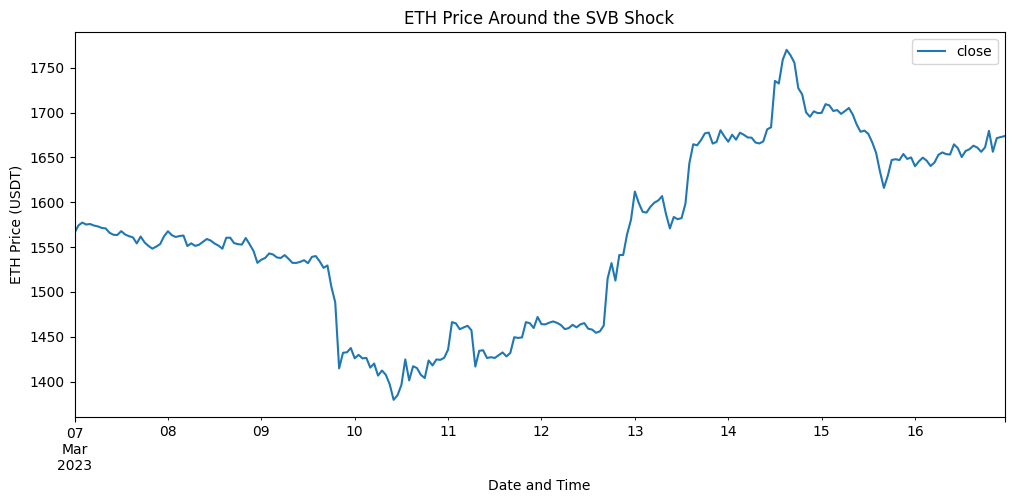

In [22]:
ax = svb_eth_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="ETH Price Around the SVB Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Price (USDT)")

Text(0, 0.5, 'ETH Hourly Returns (%)')

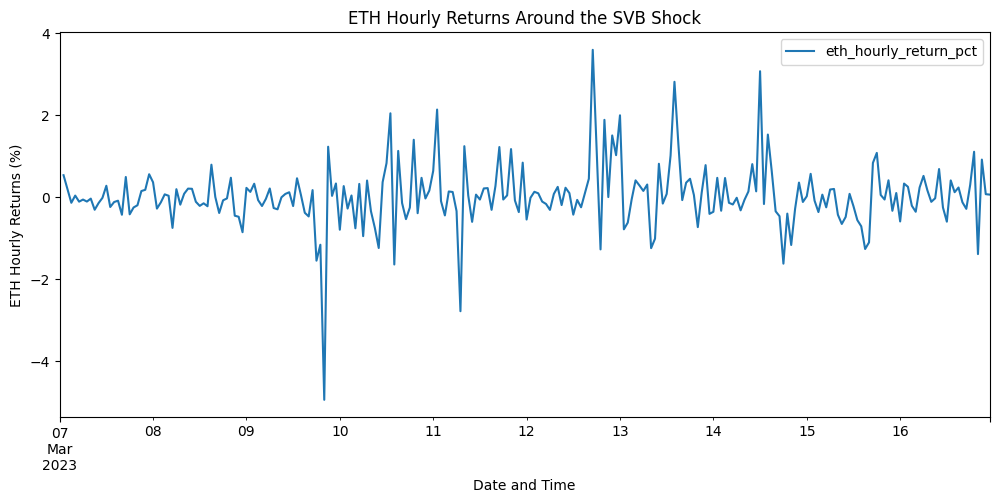

In [23]:
ax = svb_eth_detail.plot(
    x="open_time",
    y="eth_hourly_return_pct",
    figsize=(12, 5),
    title="ETH Hourly Returns Around the SVB Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Hourly Returns (%)")

### Hourly Observation

The hourly data reinforces the pattern observed in the daily analysis.

The strongest negative hourly movements in the selected window occurred on **9 March at 20:00 UTC**, when BTC declined by approximately **3.54%** and ETH by **4.94%**.

These movements occurred before the official closure of Silicon Valley Bank.

The broader BTC and ETH data therefore does not show a clear market-wide sell-off beginning with the bank failure itself.

This makes the stablecoin comparison more important: the next step examines whether the banking problem was reflected more directly in the asset whose reserves were connected to SVB.

## 3. Event Timeline and T0 Definition

The SVB case contains two important events, and they should not be treated as the same moment.

The first is the **failure of Silicon Valley Bank itself**.

The second is the later confirmation that **Circle, the company behind USDC, kept part of the cash reserves supporting USDC at SVB**.

This distinction matters because the failure of SVB did not automatically tell the market how much USDC was exposed to the bank. The size of that connection became clear only after Circle publicly disclosed it.

### T0 Definition

For this project, **T0 is the timestamp of a specific publicly observable event that provides a reference point for comparing conditions before and after the event.**

For the SVB case, the failure of the bank itself is an important part of the timeline.

However, the direct connection to the stablecoin market became clear when Circle publicly confirmed how much of the reserves supporting USDC remained at SVB.

Therefore, the Circle disclosure is used as the primary T0:

**11 March 2023, 03:11 UTC**

The distinction is simple:

- **SVB closure** → the bank failed.
- **Circle disclosure** → the market learned how much of the money supporting USDC was affected.

This timestamp allows the analysis to compare the behaviour of USDC with the modelled USDT operational balance around the same event.

In [24]:
svb_t0 = pd.Timestamp(
    "2023-03-11 03:11:00",
    tz="UTC"
)

## 4. Stablecoin Stability During the SVB Crisis

The BTC and ETH analysis provides the broader market context, but the main question in this case concerns the stablecoins.

In the modelled payment scenario, the operational balance is held in **USDT**.

USDC is included as an event-specific comparison because Circle had disclosed reserve exposure to the failed bank.

This creates a useful natural comparison:

> **How did the modelled USDT balance behave while a different major stablecoin faced a direct problem with part of its supporting reserves?**

The analysis compares:

1. how far USDT and USDC moved from their intended $1 value;
2. how persistent any deviation became;
3. how quickly the more severely affected stablecoin normalized.

In [25]:
usdt_svb_hourly = pd.read_csv('../data/processed/hourly/coinbase/usdt_svb_hourly_processed.csv', parse_dates=["timestamp"])
usdt_svb_hourly.head()

,timestamp,low,high,open,close,volume
0,2023-02-24 00:00:00+00:00,0.94304,0.94389,0.94389,0.94304,31919.45
1,2023-02-24 01:00:00+00:00,0.94250,0.94390,0.94301,0.94335,82538.35
2,2023-02-24 02:00:00+00:00,0.94308,0.94380,0.94320,0.94340,4434.11
3,2023-02-24 03:00:00+00:00,0.94297,0.94343,0.94340,0.94343,7266.42
4,2023-02-24 04:00:00+00:00,0.94338,0.94380,0.94343,0.94350,6760.20


In [26]:
usdc_svb_hourly = pd.read_csv('../data/processed/hourly/coinbase/usdc_svb_hourly_processed.csv', parse_dates=["timestamp"])
usdc_svb_hourly.head()

,timestamp,low,high,open,close,volume
0,2023-02-24 00:00:00+00:00,0.9431,0.9437,0.9435,0.9431,533.81
1,2023-02-24 01:00:00+00:00,0.9424,0.9437,0.9430,0.9433,1819.16
2,2023-02-24 02:00:00+00:00,0.9430,0.9440,0.9432,0.9435,531.36
3,2023-02-24 03:00:00+00:00,0.9426,0.9438,0.9437,0.9435,7719.24
4,2023-02-24 04:00:00+00:00,0.9430,0.9436,0.9430,0.9435,380.75


In [27]:
eur_svb_hourly = pd.read_csv('../data/processed/fx/eur_usd_svb_hourly_processed.csv', parse_dates=["timestamp"])
eur_svb_hourly.head()

,timestamp,open,high,low,close,volume
0,2023-02-24 00:00:00+00:00,1.05973,1.06071,1.05948,1.06071,14269260000
1,2023-02-24 01:00:00+00:00,1.06069,1.06141,1.05932,1.06010,24791490000
2,2023-02-24 02:00:00+00:00,1.06010,1.06061,1.05946,1.05969,12609240000
3,2023-02-24 03:00:00+00:00,1.05969,1.06051,1.05968,1.05998,7864230000
4,2023-02-24 04:00:00+00:00,1.05998,1.06013,1.05956,1.05998,7676550000


Before constructing the USD-equivalent prices, the analysis checks whether all three datasets cover the selected event window around T0.

In [28]:
for name, df in {
    "USDT/EUR": usdt_svb_hourly,
    "USDC/EUR": usdc_svb_hourly,
    "EUR/USD": eur_svb_hourly
}.items():
    event_data = df[
        (df["timestamp"] >= svb_t0 - pd.Timedelta(days=3))
        & (df["timestamp"] <= svb_t0 + pd.Timedelta(days=3))
    ]

    print(
        name,
        "| rows:", len(event_data),
        "| start:", event_data["timestamp"].min(),
        "| end:", event_data["timestamp"].max()
    )

USDT/EUR | rows: 144 | start: 2023-03-08 04:00:00+00:00 | end: 2023-03-14 03:00:00+00:00
USDC/EUR | rows: 144 | start: 2023-03-08 04:00:00+00:00 | end: 2023-03-14 03:00:00+00:00
EUR/USD | rows: 97 | start: 2023-03-08 04:00:00+00:00 | end: 2023-03-14 03:00:00+00:00


### Data Coverage and FX Weekend Limitation

Crypto markets trade continuously, while the EUR/USD foreign-exchange market does not provide the same weekend coverage.

This is particularly important for the SVB case because T0 occurred on **Saturday, 11 March**.

USDT/EUR and USDC/EUR therefore contain more hourly observations during the event window than EUR/USD.

For weekend stablecoin observations, the most recent available EUR/USD rate is carried forward until a new FX observation becomes available.

A separate flag is retained to show whether the FX rate was directly observed or carried forward.

This allows approximate USD stablecoin values to be calculated during the weekend while keeping the limitation visible in the analysis.

### Converting EUR Prices to Approximate USD Values

Coinbase quotes USDT and USDC against EUR, while both stablecoins are designed to remain close to **$1**.

The EUR prices are therefore combined with the EUR/USD benchmark:

`stablecoin/EUR × EUR/USD = approximate stablecoin/USD`

This helps separate stablecoin-specific movements from changes in the EUR/USD exchange rate.

In [29]:
svb_stablecoin_fx = (
    usdc_svb_hourly[["timestamp", "close"]]
    .rename(columns={"close": "usdc_eur_close"})
    .merge(
        usdt_svb_hourly[["timestamp", "close"]]
        .rename(columns={"close": "usdt_eur_close"}),
        on="timestamp",
        how="left"
    )
    .merge(
        eur_svb_hourly[["timestamp", "close"]]
        .rename(columns={"close": "eur_usd_close"}),
        on="timestamp",
        how="left"
    )
    .sort_values("timestamp")
)

svb_stablecoin_fx["fx_rate_observed"] = (
    svb_stablecoin_fx["eur_usd_close"].notna()
)

svb_stablecoin_fx["eur_usd_benchmark"] = (
    svb_stablecoin_fx["eur_usd_close"].ffill()
)

In [30]:
svb_stablecoin_fx["usdc_usd_implied"] = (
    svb_stablecoin_fx["usdc_eur_close"]
    * svb_stablecoin_fx["eur_usd_benchmark"]
)

svb_stablecoin_fx["usdt_usd_implied"] = (
    svb_stablecoin_fx["usdt_eur_close"]
    * svb_stablecoin_fx["eur_usd_benchmark"]
)

In [31]:
svb_stress_window = svb_stablecoin_fx[
    (svb_stablecoin_fx["timestamp"] >= svb_t0 - pd.Timedelta(days=3))
    & (svb_stablecoin_fx["timestamp"] <= svb_t0 + pd.Timedelta(days=3))
].copy()

svb_stress_window[
    ["usdt_usd_implied", "usdc_usd_implied"]
].describe()

,usdt_usd_implied,usdc_usd_implied
count,144.000000,144.000000
mean,0.999227,0.978908
std,0.003563,0.029489
min,0.983191,0.854713
25%,0.999237,0.961286
50%,0.999825,0.994711
75%,1.000570,0.999923
max,1.008070,1.000844


The summary statistics already indicate substantially greater instability in USDC than in USDT during the selected event window. However, the minimum value and its timing are more informative than the period average for this event study.

In [32]:
usdc_min_idx = svb_stress_window["usdc_usd_implied"].idxmin()
usdt_min_idx = svb_stress_window["usdt_usd_implied"].idxmin()

svb_stress_window.loc[
    [usdc_min_idx, usdt_min_idx],
    [
        "timestamp",
        "usdc_usd_implied",
        "usdt_usd_implied",
        "eur_usd_benchmark",
        "fx_rate_observed"
    ]
]

,timestamp,usdc_usd_implied,usdt_usd_implied,eur_usd_benchmark,fx_rate_observed
361,2023-03-11 07:00:00+00:00,0.854713,1.000921,1.06387,False
409,2023-03-13 07:00:00+00:00,0.970193,0.983191,1.07251,True


### Peg Stress Severity

The two stablecoins behaved very differently during the same event window.

USDC reached an approximate implied value of **$0.8547**, around **14.53% below its intended $1 value**.

The minimum occurred at **07:00 UTC on 11 March**, less than four hours after T0.

At the same timestamp, USDT remained close to its intended value at approximately **$1.0009**.

This contrast is important for the modelled payment scenario.

The USDT operational balance remained comparatively stable, while the stablecoin with direct disclosed reserve exposure to SVB experienced a much larger valuation shock.

The USDC minimum occurred during the weekend, when the EUR/USD benchmark was carried forward rather than directly observed. This methodological limitation is retained explicitly in the analysis.

In [33]:
svb_stress_window["usdc_peg_deviation_pct"] = (
    svb_stress_window["usdc_usd_implied"] - 1
) * 100

svb_stress_window["usdt_peg_deviation_pct"] = (
    svb_stress_window["usdt_usd_implied"] - 1
) * 100

In [34]:
svb_stress_window.loc[
    [usdc_min_idx, usdt_min_idx],
    [
        "timestamp",
        "usdc_usd_implied",
        "usdc_peg_deviation_pct",
        "usdt_usd_implied",
        "usdt_peg_deviation_pct",
        "fx_rate_observed"
    ]
]

,timestamp,usdc_usd_implied,usdc_peg_deviation_pct,usdt_usd_implied,usdt_peg_deviation_pct,fx_rate_observed
361,2023-03-11 07:00:00+00:00,0.854713,-14.528684,1.000921,0.092081,False
409,2023-03-13 07:00:00+00:00,0.970193,-2.980745,0.983191,-1.680863,True


### Peg Stress Persistence

The lowest price shows how severe the deviation became, but not how persistent the instability was.

To measure persistence, the analysis counts hourly observations below several price levels:

- **$0.995** — initial peg stress
- **$0.990** — more noticeable deviation
- **$0.980** — material depeg
- **$0.950** — severe depeg
- **$0.900** — extreme depeg

The same thresholds are applied to USDT and USDC so their behaviour can be compared directly.

In [35]:
thresholds = [0.995, 0.990, 0.980, 0.950, 0.900]

for asset in ["usdt", "usdc"]:
    print(f"\n{asset.upper()}")

    for threshold in thresholds:
        hours_below = (
            svb_stress_window[f"{asset}_usd_implied"] < threshold
        ).sum()

        print(
            f"Hours below ${threshold:.3f}:",
            hours_below
        )


USDT
Hours below $0.995: 15
Hours below $0.990: 5
Hours below $0.980: 0
Hours below $0.950: 0
Hours below $0.900: 0

USDC
Hours below $0.995: 75
Hours below $0.990: 66
Hours below $0.980: 48
Hours below $0.950: 22
Hours below $0.900: 4


### Persistence Finding

USDC experienced both deeper and more persistent peg stress than USDT.

Within the selected event window:

- USDC recorded **75 hourly observations below $0.995**;
- **48 observations below $0.980**;
- **22 observations below $0.950**;
- and **4 observations below $0.900**.

USDT showed smaller temporary deviations but recorded **no observations below $0.980**.

The difference shows that the stress was strongly concentrated in USDC rather than affecting the two stablecoins equally.

### Time to Lowest Point and Recovery

Two additional measures describe how quickly the stress developed and how long recovery took:

- **Time to low** — elapsed time between T0 and the lowest observed USDC value.
- **Recovery time** — elapsed time from the lowest point until USDC first returned to at least $0.995.

In [36]:
usdc_low_time = svb_stress_window.loc[
    svb_stress_window["usdc_usd_implied"].idxmin(),
    "timestamp"
]

usdc_recovery = svb_stress_window[
    (svb_stress_window["timestamp"] > usdc_low_time)
    & (svb_stress_window["usdc_usd_implied"] >= 0.995)
].iloc[0]

usdc_recovery_time = (
    usdc_recovery["timestamp"] - usdc_low_time
)

print("USDC low:", usdc_low_time)
print("Recovery:", usdc_recovery["timestamp"])
print("Recovery time:", usdc_recovery_time)

USDC low: 2023-03-11 07:00:00+00:00
Recovery: 2023-03-13 16:00:00+00:00
Recovery time: 2 days 09:00:00


In [37]:
time_to_usdc_low = usdc_low_time - svb_t0

time_to_usdc_low

Timedelta('0 days 03:49:00')

### Recovery Finding

USDC reached its lowest observed value approximately **3 hours and 49 minutes after T0**.

From that lowest point, it took approximately **57 hours** to return to at least **$0.995**.

The strongest loss of price stability therefore developed quickly after the reserve exposure became public, while normalization took more than two days.

## 5. SVB Case Conclusion

The SVB case shows that stablecoin risk can originate outside the crypto market itself.

BTC and ETH were already moving before the bank was officially closed, and the broader market data does not show a distinct crypto sell-off beginning with the SVB failure.

The much clearer difference appears in the stablecoin comparison.

USDC, whose issuer had disclosed that part of its supporting reserves remained at SVB, experienced a severe and persistent deviation from its intended $1 value.

USDT remained substantially more stable during the same event window.

For the payment scenario modelled in this project, the USDT operational balance therefore remained comparatively resilient during this event.

However, the USDC experience demonstrates an important limitation of the broader strategy:

> **Converting volatile crypto into a stablecoin reduces direct BTC and ETH exposure, but the resulting risk still depends on the specific stablecoin and the infrastructure supporting its reserves.**

Stablecoins should therefore not be treated as interchangeable simply because they are all designed to remain close to $1.